In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize, least_squares
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from tqdm import tqdm
from adjustText import adjust_text

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'DejaVu Sans'
#rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Arial']

pd.set_option("display.max_colwidth", None)

In [2]:
# Parameters
fc_thresh = 1
p_thresh = 0.05

In [3]:
# Paths
out_dir_V = Path("../../out/D39V/diff_expr/")
data_dir_V = Path("../../data/reference/D39V/")
contrast_file_V = out_dir_V / "contrast_table.tsv"
gff_V = data_dir_V / "D39V.gff3"

In [4]:
# load data
contrasts_V = pd.read_csv(contrast_file_V, sep="\t")
ref_V = pd.read_csv(gff_V, sep="\t", comment="#", header=None,
                     names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])

In [5]:
# Filter for genes or CDS
genes = ref_V[ref_V["type"].isin(["gene", "CDS"])]

# Function to extract attributes
def parse_attributes(attr_str):
    attrs = {}
    for item in attr_str.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            attrs[k] = v

    return pd.Series({
        "locus_tag": attrs.get("locus_tag", ""),
        "gene_id": attrs.get("gene", attrs.get("ID", "")),
        "gene_name": attrs.get("Name", attrs.get("gene", "")),
        "product": attrs.get("product", "")
    })

# Apply parsing
gene_attr = genes["attributes"].apply(parse_attributes)

# Combine with positional info
gene_df_V = pd.concat([genes[["seqid", "start", "end", "strand"]], gene_attr], axis=1)

In [6]:
dgVf = gene_df_V[gene_df_V.duplicated(subset="locus_tag", keep='first')]

In [7]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('com', case=False, na=False)).any(axis=1)
com = dgVf[mask]

In [8]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('lac', case=False, na=False)).any(axis=1)
lac = dgVf[mask]
lac

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
2266,CP027540.1,429824,430168,+,SPV_0426,lacF-1,AVN85587.1,Lactose-specific PTS IIA component
2269,CP027540.1,430178,431590,+,SPV_0427,lacG-1,AVN85588.1,6-phospho-beta-galactosidase
2272,CP027540.1,431659,433338,+,SPV_0428,lacE-1,AVN85589.1,Lactose-specific PTS IIBC components
5324,CP027540.1,1073768,1074529,+,SPV_1044,lacR,AVN86153.1,Lactose phosphotransferase system repressor
5329,CP027540.1,1075027,1076433,-,SPV_1046,lacG-2,AVN86154.1,6-phospho-beta-galactosidase
5332,CP027540.1,1076642,1078333,-,SPV_1047,lacE-2,AVN86155.1,Lactose-specific PTS IIBC components
5334,CP027540.1,1078333,1078650,-,SPV_1048,lacF-2,AVN86156.1,Lactose-specific PTS IIA component
5338,CP027540.1,1078686,1079522,-,SPV_1049,lacT,AVN86157.1,Beta-glucoside bgl operon antiterminator LacT%2C BglG family
5351,CP027540.1,1080737,1081666,-,SPV_1051,lacC,AVN86158.1,Tagatose-6-phosphate kinase LacC
5355,CP027540.1,1081677,1082192,-,SPV_1052,lacB,AVN86159.1,Galactose-6-phosphate isomerase%2C LacB subunit


In [9]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('gal', case=False, na=False)).any(axis=1)
gal = dgVf[mask]
gal

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
358,CP027540.1,71832,72869,+,SPV_0071,galM,AVN85244.1,Aldose 1-epimerase
7194,CP027540.1,1448715,1449734,-,SPV_1432,galE-1,AVN86511.1,UDP-glucose 4-epimerase
8118,CP027540.1,1627039,1628019,-,SPV_1612,galE-2,AVN86689.1,UDP-glucose 4-epimerase
8121,CP027540.1,1628032,1629507,-,SPV_1613,galT-1,AVN86690.1,Galactose-1-phosphate uridylyltransferase
8213,CP027540.1,1647079,1648560,-,SPV_1633,galT-2,AVN86704.1,Galactose-1-phosphate uridylyltransferase
8216,CP027540.1,1648579,1649757,-,SPV_1634,galK,AVN86705.1,Galactokinase
8227,CP027540.1,1649921,1650928,+,SPV_1635,galR,AVN86706.1,Galactose operon repressor%2C GalR-LacI family
9566,CP027540.1,1888745,1889644,+,SPV_1919,galU,AVN86922.1,UTP--glucose-1-phosphate uridylyltransferase


In [10]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('pgm', case=False, na=False)).any(axis=1)
pgm = dgVf[mask]
pgm

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
6639,CP027540.1,1341636,1343354,+,SPV_1326,pgm,AVN86409.1,Phosphoglucomutase


In [11]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('aro', case=False, na=False)).any(axis=1)
aro = dgVf[mask]
aro

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
6091,CP027540.1,1233854,1234330,-,SPV_1204,aroK,AVN86301.1,Shikimate kinase I
6094,CP027540.1,1234323,1235606,-,SPV_1205,aroA,AVN86302.1,5-Enolpyruvylshikimate-3-phosphate synthase
6108,CP027540.1,1237160,1238326,-,SPV_1208,aroC,AVN86305.1,Chorismate synthase
6111,CP027540.1,1238336,1239403,-,SPV_1209,aroB,AVN86306.1,3-dehydroquinate synthase
6114,CP027540.1,1239422,1240276,-,SPV_1210,aroE,AVN86307.1,Shikimate/quinate 5-dehydrogenase I beta
6116,CP027540.1,1240266,1240943,-,SPV_1211,aroD,AVN86308.1,3-dehydroquinate dehydratase I
7593,CP027540.1,1532234,1533265,-,SPV_1510,aroF,AVN86586.1,2-keto-3-deoxy-D-arabino-heptulosonate-7-phosphate synthase I alpha
7595,CP027540.1,1533267,1534298,-,SPV_1511,aroG,AVN86587.1,2-keto-3-deoxy-D-arabino-heptulosonate-7-phosphate synthase I alpha


In [12]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('sat', case=False, na=False)).any(axis=1)
sat = dgVf[mask]
sat

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
7504,CP027540.1,1509247,1510086,-,SPV_1493,satC,AVN86568.1,ABC transporter%2C putative N-acetylneuraminate transport system permease protein 2
7507,CP027540.1,1510102,1510989,-,SPV_1494,satB,AVN86569.1,ABC transporter%2C putative N-acetylneuraminate transport system permease protein 1
7510,CP027540.1,1511220,1512548,-,SPV_1495,satA,AVN86570.1,ABC transporter%2C putative N-acetylneuraminate-binding protein


In [13]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('shp', case=False, na=False)).any(axis=1)
shp = dgVf[mask]
shp

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
820,CP027540.1,150808,150888,-,SPV_2573,shp144,XFU36293.1,Signal peptide in Rgg144/SHP144 quorum-sensing system
5025,CP027540.1,1015296,1015367,-,SPV_2282,shp939,AVN86102.1,Signal peptide in Rgg939/SHP939 quorum-sensing system
7621,CP027540.1,1539963,1540064,-,SPV_2542,shp1518,USH90147.1,Pheromone in Rgg1518/SHP1518 quorum-sensing system


In [14]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('vp', case=False, na=False)).any(axis=1)
vp = dgVf[mask]
vp

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
832,CP027540.1,151109,151342,+,SPV_0145,vp1,AVN85321.1,Virulence peptide with glycine-glycine motif
841,CP027540.1,152053,152718,+,SPV_0147,vpoB,AVN85323.1,(Putative) Abi family transmembrane protease
844,CP027540.1,152790,154016,+,SPV_0148,vpoC,AVN85324.1,(Putative) Major facilitator superfamily 1 type transporter
848,CP027540.1,154226,154822,+,SPV_0149,vpoD,AVN85325.1,(Putative) Branched chain amino acid transporter


In [15]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('rtg', case=False, na=False)).any(axis=1)
rtg = dgVf[mask]
rtg

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
599,CP027540.1,112681,113544,-,SPV_0112,rtgR,AVN85283.1,Transcriptional regulator of rtg locus
605,CP027540.1,113770,113814,+,SPV_2467,rtgS1,USH90072.1,Pheromone in Rtg/SHP-like quorum-sensing system RtgR/RtgS
614,CP027540.1,116222,116689,+,SPV_0114,rtgX,AVN85284.1,(Putative) GyrI-like protein
616,CP027540.1,116686,118038,+,SPV_0115,rtgB,AVN85285.1,(Putative) RtgA transporter accessory protein
619,CP027540.1,118184,118564,+,SPV_0116,rtgC,AVN85286.1,Double-glycine peptide transported by RtgAB
630,CP027540.1,119733,119777,+,SPV_2470,rtgS2,USH90075.1,Pheromone in Rtg/SHP-like quorum-sensing system RtgR/RtgS
633,CP027540.1,119812,119976,+,SPV_2099,rtgH,AVN85287.1,Protein in rtg locus (putative)
636,CP027540.1,120144,120515,+,SPV_0117,rtgK,AVN85288.1,(Putative) Double-glycine containing bacteriocin precursor peptide
638,CP027540.1,120523,120735,+,SPV_2100,rtgL,AVN85289.1,Protein in rtg locus (putative)
655,CP027540.1,121540,122598,+,SPV_0119,rtgP,AVN85292.1,(Putative) Integral membrane protein


In [16]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('cps', case=False, na=False)).any(axis=1)
cps = dgVf[mask]
cps

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
323,CP027540.1,64781,65524,-,SPV_0064,cpsR,AVN85237.1,Transcriptional regulator%2C GntR family
1750,CP027540.1,314201,315646,+,SPV_0315,cps2A,AVN85486.1,Exopolysaccharide biosynthesis transcriptional regulator Cps2A
1753,CP027540.1,315648,316379,+,SPV_0316,cps2B,AVN85487.1,Tyrosine-protein phosphatase Cps2B
1756,CP027540.1,316388,317080,+,SPV_0317,cps2C,AVN85488.1,Capsular biosynthesis protein Cps2C
1759,CP027540.1,317090,317770,+,SPV_0318,cps2D,AVN85489.1,Tyrosine-protein kinase Cps2D
1761,CP027540.1,317785,319152,+,SPV_0319,cps2E,AVN85490.1,Undecaprenyl-phosphate galactosephosphotransferase Cps2E
1763,CP027540.1,319184,320368,+,SPV_0320,cps2T,AVN85491.1,Alpha-D-GlcNAc alpha-1%2C2-L-rhamnosyltransferase Cps2T
1767,CP027540.1,320361,321305,+,SPV_0321,cps2F,AVN85492.1,Alpha-L-Rha alpha-1%2C3-L-rhamnosyltransferase Cps2F
1770,CP027540.1,321321,322367,+,SPV_0322,cps2G,AVN85493.1,Glycosyltransferase Cps2G
1772,CP027540.1,322408,323571,+,SPV_0323,cps2H,AVN85494.1,Capsular synthesis protein Cps2H


In [17]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('mur', case=False, na=False)).any(axis=1)
mur = dgVf[mask]
mur

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
2816,CP027540.1,548306,549526,+,SPV_0535,murM,AVN85689.1,tRNA-dependent lipid II--L-alanine/serine ligase MurM
2819,CP027540.1,549531,550763,+,SPV_0536,murN,AVN85690.1,tRNA-dependent lipid II-Ala--L-alanine ligase MurN
3156,CP027540.1,623359,624711,+,SPV_0598,murD,AVN85749.1,UDP-N-acetylmuramoylalanine--D-glutamate ligase
3158,CP027540.1,624715,625773,+,SPV_0599,murG,AVN85750.1,UDP-N-acetylglucosamine--N-acetylmuramyl-(pentapeptide) pyrophosphoryl-undecaprenol N-acetylglucosamine transferase
4908,CP027540.1,982033,983292,-,SPV_0967,murA-1,AVN86076.1,UDP-N-acetylglucosamine 1-carboxyvinyltransferase
6182,CP027540.1,1254616,1255566,-,SPV_1222,murB,AVN86319.1,UDP-N-acetylenolpyruvoylglucosamine reductase
6749,CP027540.1,1362016,1363350,-,SPV_1349,murC,AVN86432.1,UDP-N-acetylmuramate--alanine ligase
6797,CP027540.1,1375387,1376832,+,SPV_1359,murE,AVN86439.1,UDP-N-acetylmuramoylalanyl-D-glutamate--L-lysine ligase
7119,CP027540.1,1436380,1437723,+,SPV_1416,murT,AVN86496.1,Mur ligase family protein
7461,CP027540.1,1498921,1500294,-,SPV_1483,murF,AVN86559.1,UDP-N-acetylmuramoyl-tripeptide--D-alanyl-D-alanine ligase


In [18]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('adh', case=False, na=False)).any(axis=1)
adh = dgVf[mask]
adh

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1476,CP027540.1,263864,264883,-,SPV_0265,adhA,AVN85438.1,Alcohol dehydrogenase
8231,CP027540.1,1650974,1652011,-,SPV_1636,adhB,AVN86707.1,Alcohol dehydrogenase
9190,CP027540.1,1819686,1822337,-,SPV_1834,adhE,AVN86860.1,Bifunctional acetaldehyde dehydrogenase/alcohol dehydrogenase
9313,CP027540.1,1844080,1845138,-,SPV_1865,adh,AVN86888.1,Putative Zn-dependent alcohol dehydrogenase
9919,CP027540.1,1958292,1959443,-,SPV_1985,adh2,AVN86987.1,Lactaldehyde dehydrogenase involved in fucose or rhamnose utilization


In [19]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('scr', case=False, na=False)).any(axis=1)
scr = dgVf[mask]
scr

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
7714,CP027540.1,1553456,1554343,-,SPV_1531,scrK,AVN86608.1,Fructokinase
7720,CP027540.1,1554492,1556375,-,SPV_1532,scrA,AVN86609.1,Sucrose-specific PTS IIBCA components
7733,CP027540.1,1556752,1558206,+,SPV_1534,scrB,AVN86611.1,Sucrose-6-phosphate hydrolase
7735,CP027540.1,1558187,1559152,+,SPV_1535,scrR,AVN86612.1,Sucrose operon repressor ScrR%2C LacI family


In [20]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('arg', case=False, na=False)).any(axis=1)
arg = dgVf[mask]
arg

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
591,CP027540.1,109776,110972,+,SPV_0110,argG,AVN85281.1,Argininosuccinate synthase
595,CP027540.1,111001,112392,+,SPV_0111,argH,AVN85282.1,Argininosuccinate lyase
4104,CP027540.1,800875,801345,-,SPV_0786,argR2,AVN85915.1,Arginine pathway regulatory protein ArgR2
9502,CP027540.1,1876446,1876892,-,SPV_1904,argR1,AVN86908.1,Arginine pathway regulatory protein ArgR1
9520,CP027540.1,1877040,1878731,+,SPV_1905,argS,AVN86909.1,Arginyl-tRNA synthetase


In [21]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('lic', case=False, na=False)).any(axis=1)
lic = dgVf[mask]
lic

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
5701,CP027540.1,1154827,1155516,-,SPV_1123,licC,AVN86225.1,Cholinephosphate cytidylyltransferase LicC
5704,CP027540.1,1155528,1156406,-,SPV_1124,licB,AVN86226.1,Choline permease LicB
5706,CP027540.1,1156396,1157265,-,SPV_1125,licA,AVN86227.1,Choline kinase LicA
5730,CP027540.1,1160849,1161652,+,SPV_1129,licD1,AVN86231.1,Lipopolysaccharide cholinephosphotransferase LicD1
5733,CP027540.1,1161654,1162463,+,SPV_1130,licD2,AVN86232.1,Lipopolysaccharide cholinephosphotransferase LicD2
6076,CP027540.1,1230614,1231459,-,SPV_1201,licD3,AVN86298.2,Lipopolysaccharide cholinephosphotransferase LicD3


In [22]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('fts', case=False, na=False)).any(axis=1)
fts = dgVf[mask]
fts

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
54,CP027540.1,12174,14132,+,SPV_0013,ftsH,AVN85201.1,Cell division protein FtsH
1688,CP027540.1,302446,302763,+,SPV_0305,ftsL,AVN85478.1,Cell division protein FtsL
3461,CP027540.1,677465,678157,+,SPV_0659,ftsE,AVN85803.1,Cell division transporter%2C ATP-binding protein FtsE
3463,CP027540.1,678150,679076,+,SPV_0660,ftsX,AVN85804.1,Cell division protein FtsX
4044,CP027540.1,786057,788360,+,SPV_0774,ftsK,AVN85904.1,DNA translocase FtsK
4981,CP027540.1,999483,1000712,-,SPV_0952,ftsW,AVN86090.1,Cell division protein FtsW
5604,CP027540.1,1132234,1133511,-,SPV_1101,ftsY,AVN86204.1,Signal recognition particle receptor FtsY
7444,CP027540.1,1494660,1495919,-,SPV_1479,ftsZ,AVN86555.1,Cell division protein FtsZ
7448,CP027540.1,1495936,1497309,-,SPV_1480,ftsA,AVN86556.1,Cell division protein FtsA


In [23]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('clp', case=False, na=False)).any(axis=1)
clp = dgVf[mask]
clp

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1710,CP027540.1,306558,308663,+,SPV_0308,clpL,AVN85481.1,Putative ATP-dependent Clp proteinase ATP-binding subunit ClpL
3406,CP027540.1,669424,670014,+,SPV_0650,clpP,AVN85794.1,ATP-dependent Clp protease proteolytic subunit ClpP
3760,CP027540.1,731934,734192,-,SPV_0717,clpE,AVN85855.1,ATP-dependent Clp protease ATP-binding subunit ClpE
6993,CP027540.1,1419415,1420647,-,SPV_1399,clpX,AVN86479.1,ATP-dependent Clp protease ATP-binding subunit ClpX
10106,CP027540.1,2000918,2003350,-,SPV_2022,clpC,AVN87025.1,ATP-dependent Clp protease ATP-binding subunit ClpC


In [24]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('dna', case=False, na=False)).any(axis=1)
dna = dgVf[mask]
dna

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
2,CP027540.1,1,1362,+,SPV_0001,dnaA,AVN85189.1,Chromosomal replication initiator protein DnaA
11,CP027540.1,1521,2657,+,SPV_0002,dnaN,AVN85190.1,DNA polymerase III beta subunit
2449,CP027540.1,470045,471868,+,SPV_0460,dnaK,AVN85622.1,Chaperone protein DnaK
2454,CP027540.1,472628,473746,+,SPV_0461,dnaJ,AVN85624.1,Chaperone protein DnaJ
3969,CP027540.1,771080,772735,+,SPV_0760,dnaX,AVN85892.1,DNA polymerase III subunits gamma and tau
4115,CP027540.1,803981,807082,+,SPV_0788,dnaE,AVN85917.1,DNA polymerase III alpha subunit
4528,CP027540.1,891990,892580,+,SPV_0879,dnaQ,AVN86004.1,DNA polymerase III epsilon subunit
4953,CP027540.1,991810,993570,-,SPV_0957,dnaG,AVN86085.1,DNA primase
7029,CP027540.1,1424898,1425575,-,SPV_1405,dnaD,AVN86485.1,Chromosome replication initiation protein DnaD
7648,CP027540.1,1544179,1545075,-,SPV_1521,dnaI,AVN86598.1,Helicase loader DnaI


In [25]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('cel', case=False, na=False)).any(axis=1)
cel = dgVf[mask]
cel

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1555,CP027540.1,275005,276441,+,SPV_0277,celA,AVN85451.1,6-phospho-beta-glucosidase
1566,CP027540.1,276862,277176,+,SPV_0279,celB,AVN85453.1,Cellobiose-specific PTS IIB component
1573,CP027540.1,277300,279273,+,SPV_0280,celR,AVN85454.1,Transcriptional antiterminator of lichenan operon%2C BglG family
1576,CP027540.1,279283,279597,+,SPV_0281,celC,AVN85455.1,Cellobiose-specific PTS IIA component
1582,CP027540.1,280202,281548,+,SPV_0283,celD,AVN85457.1,Cellobiose-specific PTS IIC component


In [26]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('ula', case=False, na=False)).any(axis=1)
ula = dgVf[mask]
ula

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1512,CP027540.1,268528,269472,+,SPV_0269,sulA,AVN85443.1,Dihydropteroate synthase
4738,CP027540.1,949253,951532,-,SPV_1002,pulA,AVN86043.1,Putative glycogen debranching enzyme
9216,CP027540.1,1823940,1825916,-,SPV_1839,ulaH,AVN86864.1,Transketolase
9221,CP027540.1,1826030,1827121,-,SPV_1840,ulaG,AVN86865.1,Putative L-ascorbate-6-phosphate lactonase UlaG
9225,CP027540.1,1827233,1828906,-,SPV_1841,ulaR,AVN86866.1,Transcriptional antiterminator
9229,CP027540.1,1829085,1829789,-,SPV_1842,ulaF,AVN86867.1,L-ribulose-5-phosphate 4-epimerase
9231,CP027540.1,1829791,1830654,-,SPV_1843,ulaE,AVN86868.1,L-xylulose 5-phosphate 3-epimerase
9233,CP027540.1,1830658,1831323,-,SPV_1844,ulaD,AVN86869.1,3-keto-L-gulonate 6-phosphate decarboxylase
9237,CP027540.1,1831340,1831825,-,SPV_1845,ulaC,AVN86870.1,Ascorbate-specific PTS IIA component
9240,CP027540.1,1831902,1832183,-,SPV_1846,ulaB,AVN86871.1,Ascorbate-specific PTS IIB component


In [27]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('mal', case=False, na=False)).any(axis=1)
mal = dgVf[mask]
mal

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
3473,CP027540.1,679362,681542,+,SPV_0661,malT,AVN85805.1,Maltose- and glucose-specific PTS IICBA components
9646,CP027540.1,1903725,1905983,-,SPV_1932,malP,AVN86936.1,Maltodextrin phosphorylase
9649,CP027540.1,1906009,1907526,-,SPV_1933,malQ,AVN86937.1,4-alpha-glucanotransferase (amylomaltase)
9672,CP027540.1,1908076,1909347,+,SPV_1934,malX,AVN86938.1,Maltose/maltodextrin ABC transporter%2C substrate binding periplasmic protein MalX
9676,CP027540.1,1909458,1910750,+,SPV_1935,malC,AVN86939.1,Maltose/maltodextrin ABC transporter%2C permease protein MalC
9679,CP027540.1,1910752,1911594,+,SPV_1936,malD,AVN86940.1,Maltose/maltodextrin ABC transporter%2C permease protein MalD
9688,CP027540.1,1911847,1912647,+,SPV_1937,malA,AVN86941.1,Maltodextrose utilization protein MalA
9691,CP027540.1,1912657,1913643,+,SPV_1938,malR,AVN86942.1,Maltose operon transcriptional repressor MalR%2C LacI family


In [28]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('pyr', case=False, na=False)).any(axis=1)
pyr = dgVf[mask]
pyr

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
2348,CP027540.1,445010,446617,+,SPV_0442,pyrG,AVN85603.1,CTP synthase
3187,CP027540.1,632401,633102,+,SPV_0608,pyrF,AVN85756.1,Orotidine 5'-phosphate decarboxylase
3190,CP027540.1,633136,633768,+,SPV_0609,pyrE,AVN85757.1,Orotate phosphoribosyltransferase
3501,CP027540.1,685850,686785,+,SPV_0665,pyrDa,AVN85809.1,Dihydroorotate dehydrogenase (fumarate)
4328,CP027540.1,851211,851948,+,SPV_0834,pyrH,AVN85961.1,Uridine monophosphate kinase
4408,CP027540.1,865168,865968,+,SPV_0851,pyrK,AVN85976.1,Dihydroorotate dehydrogenase (NAD(+))%2C electron transfer subunit
4411,CP027540.1,865979,866917,+,SPV_0852,pyrDb,AVN85977.1,Dihydroorotate dehydrogenase (NAD(+))%2C catalytic subunit
4598,CP027540.1,906760,908028,+,SPV_1030,pyrC,AVN86017.1,Dihydroorotase
5745,CP027540.1,1167356,1168279,-,SPV_1133,pyrB,AVN86235.1,Aspartate carbamoyltransferase
5748,CP027540.1,1168298,1168819,-,SPV_1134,pyrR,AVN86236.1,Bifunctional uracil phosphoribosyltransferase/pyrimidine operon regulatory protein PyrR


In [29]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('deo', case=False, na=False)).any(axis=1)
deo = dgVf[mask]
deo

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1258,CP027540.1,218966,219712,+,SPV_0230,deoR,AVN85402.1,Transcriptional regulator%2C DeoR family
3812,CP027540.1,739262,740473,+,SPV_0724,deoB,AVN85862.1,Phosphopentomutase
3830,CP027540.1,744493,745203,+,SPV_0730,deoD,AVN85865.1,Purine nucleoside phosphorylase
3870,CP027540.1,749754,750416,+,SPV_0737,deoC,AVN85873.1,Deoxyribose-phosphate aldolase


In [30]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('fab', case=False, na=False)).any(axis=1)
fab = dgVf[mask]
fab

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
2024,CP027540.1,383747,384532,+,SPV_0378,fabM,AVN85541.1,Trans-2%2Ccis-3-Decenoyl-ACP isomerase
2029,CP027540.1,384626,385060,+,SPV_0379,fabT,AVN85542.1,Transcriptional regulator of fatty acid biosynthesis FabT
2031,CP027540.1,385060,386034,+,SPV_0380,fabH,AVN85543.1,3-oxoacyl-(acyl-carrier-protein) synthase FabH
2041,CP027540.1,386437,387411,+,SPV_0382,fabK,AVN85545.1,Enoyl-(acyl-carrier-protein) reductase FabK
2045,CP027540.1,387404,388324,+,SPV_0383,fabD,AVN85546.1,Malonyl CoA-acyl carrier protein transacylase FabD
2047,CP027540.1,388358,389089,+,SPV_0384,fabG1,AVN85547.1,3-oxoacyl-[acyl-carrier protein] reductase FabG1
2054,CP027540.1,389111,390346,+,SPV_0385,fabF,AVN85548.1,3-oxoacyl-(acyl-carrier-protein) synthase FabF
2058,CP027540.1,390831,391253,+,SPV_0387,fabZ,AVN85550.1,3-hydroxyacyl-(acyl-carrier-protein) dehydratase FabZ
3665,CP027540.1,709252,709950,+,SPV_0695,fabG2,AVN85837.1,3-Ketoacyl-ACP reductase


In [31]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('pbp', case=False, na=False)).any(axis=1)
pbp = dgVf[mask]
pbp

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1692,CP027540.1,302767,305019,+,SPV_0306,pbp2x,AVN85479.1,Penicillin-binding protein 2X
1817,CP027540.1,340849,343008,-,SPV_0336,pbp1a,AVN85505.1,Multimodular transpeptidase-transglycosylase%2C penicillin-binding protein 1A
3998,CP027540.1,778496,779737,-,SPV_0767,pbp3,AVN85899.1,D-alanyl-D-alanine carboxypeptidase%2C penicillin-binding protein 3
7473,CP027540.1,1502204,1504261,-,SPV_1486,pbp2b,AVN86562.2,Penicillin-binding protein 2B
9116,CP027540.1,1804718,1806913,-,SPV_1821,pbp2a,AVN86848.1,Multimodular transpeptidase-transglycosylase%2C penicillin-binding protein 2A
9600,CP027540.1,1894025,1896490,-,SPV_1925,pbp1b,AVN86928.1,Multimodular transpeptidase-transglycosylase%2C penicillin-binding protein 1B


In [32]:
mask = dgVf[['gene_id']].apply(lambda x: x.str.contains('upp', case=False, na=False)).any(axis=1)
r = dgVf[mask]
r

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1353,CP027540.1,234367,235125,+,SPV_0243,uppS,AVN85416.1,Undecaprenyl diphosphate synthase
2207,CP027540.1,417652,418497,+,SPV_0417,uppP,AVN85577.1,Undecaprenyl-diphosphatase
3396,CP027540.1,668600,669250,+,SPV_0649,upp,AVN85793.1,Uracil phosphoribosyltransferase


# other hits of interest
locus_tag in D39 : product

* SPD_RS10420: "beta-N-acetylhexosaminidase"
* SPD_RS10425: "ROK family protein"
* SPD_RS10430: "alpha-mannosidase"
* SPD_RS02385: "endo-beta-N-acetylglucosaminidase"

In [53]:
mask = dgVf[['product']].apply(lambda x: x.str.contains('aminidase', case=False, na=False)).any(axis=1)
SPD_RS10420_SPD_RS02385 = dgVf[mask]
SPD_RS10420_SPD_RS02385

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product,pathway
318,CP027540.1,60528,64466,-,SPV_0063,strH,AVN85236.1,Beta-hexosaminidase StrH,C_amino_sugar
1813,CP027540.1,335379,340682,+,SPV_0335,eng,AVN85504.1,Endo-alpha-N-acetylgalactosaminidase Eng,NaN
2363,CP027540.1,449100,454079,+,SPV_0444,endoD,AVN85605.1,Endo-beta-N-acetylglucosaminidase EndoD,NaN
3068,CP027540.1,607014,608003,+,SPV_0579,cbpL,AVN85730.1,Endo-beta-N-acetylglucosaminidase%2C choline-binding protein CbpL,NaN
4416,CP027540.1,867016,869124,+,SPV_0853,lytB,AVN85978.1,Endo-beta-N-acetylglucosaminidase LytB,NaN


In [54]:
mask = dgVf[['product']].apply(lambda x: x.str.contains('ROK', case=False, na=False)).any(axis=1)
SPD_RS10425 = dgVf[mask]
SPD_RS10425

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product,pathway


In [55]:
mask = dgVf[['product']].apply(lambda x: x.str.contains('mannosidase', case=False, na=False)).any(axis=1)
SPD_RS10430 = dgVf[mask]
SPD_RS10430

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product,pathway
9844,CP027540.1,1940686,1943331,-,SPV_1971,cds-AVN86975.1,AVN86975.1,Alpha-mannosidase,NaN
9854,CP027540.1,1944873,1946957,+,SPV_1973,cds-AVN86977.1,AVN86977.1,Alpha-1%2C2-mannosidase,NaN


In [56]:
# patwhays

others = ["eng", "endoD", "cbpL", "lytB", "cds-AVN86975.1", "cds-AVN86977.1"]

CRISPRi_hits = [
    "yajC", "yajC-1",
    *[g for g in ula["gene_id"].to_list() if g not in ["sulA", "pulA"]],
    "aldR", "mesH",
    *mal["gene_id"].to_list(),
    "mntR", "nha2",
    *pyr["gene_id"].to_list(),
    "holA", "holB", "fer", "aliA", "aliB", "trxA", "trxB", "yabA",
    *deo["gene_id"].to_list(),
    "cdd-1", "cdd-2", "adr", "rimI", "rimP", "rimM", "nusA", "nusB", "nusG",
    "infA", "infB", "infC", "rbfA", "recR", "prfA", "prfB", "prfC",
    "regR", "srtA", "gntR", "fld", "ctpA", "ctpC", "ctpE",
    "yfmL",
    *fab["gene_id"].to_list(),
    "mreD", "mreC", "acpP",
    *pbp["gene_id"].to_list(),
    "rodA", "nox", "paaI", "cls",
    "cbiQ", "cbiO2", "cbiO1", "gtrB", "udk", "prtA",
    "def1", "def2", "pgdA",
    "trmB", "trmD", "trmFO", "trmH",
    "dexB", "mocA", "pgm", "regR",
    "upp", "uppP", "uppS", "manL","manN","manM",
    "galR", "galE-1",
    *cel["gene_id"].to_list(),
    *[g for g in cps["gene_id"].to_list() if g != "acpS"],
    "gki", "tpiA",
    *lac["gene_id"].to_list(),
    "spxA2", "ackA", "licD2", "clpP", "groEL", "groES", "grpE", "dnaK", "dnaJ", "dnaE"
]

natural_competence = com["gene_id"].to_list()

# part of rtg: cds-AVN85290.1
peptide_signaling = [
    "mutR1",
    "mutR2",
    *shp["gene_id"].to_list(),
    *vp["gene_id"].to_list(),
    *rtg["gene_id"].to_list(),
    "pspA",
    "cds-AVN85290.1",
]

# nanR = cds-AVN86565.1, cds-AVN86566.1, cds-AVN86573.1...
C_amino_sugar = [
    "bgaA","bgaC","nanA","nanB","nanP","nanE-1","nanK","nanR","nanE-2",
    *sat["gene_id"].to_list(),
    "manL","manN","manM","nagA","nagB","nagR","nagD",
    "cds-AVN86565.1","cds-AVN86566.1","yjgK","cds-AVN86573.1",
    "cds-AVN86575.1","ycjO","cds-AVN86577.1","cds-AVN86578.1",
    "cds-AVN86580.1","strH"
]

C_shikimate = [
    *aro["gene_id"].to_list(),
    "tyrA","tyrS","pheA","pheS","pheT"
]

C_leloir = [
    *gal["gene_id"].to_list(),
    "pgm", "regR"
]
C_capsule = [g for g in cps["gene_id"].to_list() if g != "acpS"]

# PTS galactose: cds-AVN85712.1, cds-AVN85713.1, cds-AVN85714.1, cds-AVN86162.1
# cel genes are part of the Cellobiose PTS
C_tagatose = [*lac["gene_id"].to_list(), "gapN", "cds-AVN85712.1", "cds-AVN85713.1", "cds-AVN85714.1", "cds-AVN86162.1"]

C_pyruvate = ["ldh", "lctO", "pfl", "pflA", "spxB", "spxA1", "spxA2", "ackA", *adh["gene_id"].to_list()]

C_glycolisis = ["malT", "gki", "pgi", "pfkA", "tpiA", "fba", "gap", "pgk", "gpmA", "gpmB1", "gpmB2", "eno", "pyk"]

C_peptidoglycan = ["glmS", "glmU", "glmM", *mur["gene_id"].to_list()]

C_glycerol = ["glpO", "glpK", "cds-AVN87012.1"]

C_sucroese = [*scr["gene_id"].to_list()]

C_arginine = [*arg["gene_id"].to_list(), "ahrC"]

C_phosphorylcholine = ["tarJ", "tarI", *lic["gene_id"].to_list()]

heat_shock = [*fts["gene_id"].to_list(), *clp["gene_id"].to_list(), "ctsR", "groEL", "groES", "hrcA", "grpE", *dna["gene_id"].to_list()]

In [57]:
dict_colors = {"natural_competence":"#0165fc",
              "peptide_signaling":"xkcd:grass green",
               "C_amino_sugar": "xkcd:pale yellow",
               "C_shikimate": "xkcd:sunflower yellow",
               "C_leloir": "xkcd:goldenrod",
               "C_capsule": "xkcd:light orange",
               "C_tagatose": "xkcd:orange",
               "C_pyruvate": "xkcd:dark orange",
               "C_glycolisis": "xkcd:pumpkin",
               "C_peptidoglycan": "xkcd:burnt orange",
               "C_glycerol": "xkcd:rust",
               "C_sucroese": "xkcd:reddish orange",
               "C_arginine": "xkcd:red",
               "C_phosphorylcholine": "xkcd:deep red",
               "heat_shock":"xkcd:maroon",
               "CRISPRi_hits":"xkcd:purple",
               "others":"#6e750e"
              }

In [36]:
def volcano(df, gff_df=None, title="", fc_thresh=1, p_thresh=0.05,
                 highlight_genes=None, highlight_color="red", save_path=None):

    # Detect columns
    fc_col = [c for c in df.columns if 'log2' in c.lower() and 'fold' in c.lower()][0]
    padj_col = [c for c in df.columns if 'padj' in c.lower()][0]
    gene_col = next((c for c in df.columns if c.lower() in ['gene','feature_id','id']), 'gene')

    df = df.copy()
    df['gene'] = df[gene_col]

    # ---- map locus_tag to gene_id ----
    if gff_df is not None:
        locus_to_geneid = dict(zip(gff_df["locus_tag"], gff_df["gene_id"]))
        df["gene_id"] = df["gene"].map(locus_to_geneid).fillna(df["gene"])
    else:
        df["gene_id"] = df["gene"]

    # stats
    df[padj_col] = df[padj_col].replace(0, 1e-300)
    df['-log10(padj)'] = -np.log10(df[padj_col])

    # labels (use gene_id for consistency)
    df['label'] = df["gene_id"]

    # ---- highlight pathway genes ----
    if highlight_genes is not None:
        highlight_set = set(highlight_genes)
        df['color'] = np.where(df['gene_id'].isin(highlight_set),
                               highlight_color, 'lightgrey')
    else:
        df['color'] = 'grey'

    # ---- Plot ----
    plt.figure(figsize=(7,7))

    if highlight_genes is not None:
        # background points (non-highlighted)
        bg = df[~df['gene_id'].isin(highlight_set)]
        plt.scatter(bg[fc_col], bg['-log10(padj)'],
                    c='lightgrey', alpha=0.3, edgecolors='none', zorder=1)

        # highlighted points (alpha = 1)
        hl = df[df['gene_id'].isin(highlight_set)]
        plt.scatter(hl[fc_col], hl['-log10(padj)'],
                    c=highlight_color, alpha=1, edgecolors='none', zorder=2)
    else:
        plt.scatter(df[fc_col], df['-log10(padj)'],
                    c='grey', alpha=0.7, edgecolors='none', zorder=1)

    plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
    plt.axvline(fc_thresh, color='grey', linestyle='--')
    plt.axvline(-fc_thresh, color='grey', linestyle='--')

    # ---- Annotate ONLY highlighted genes ----
    if highlight_genes is not None:
        sub = df[df['gene_id'].isin(highlight_set)]
        texts = [
            plt.text(r[fc_col], r['-log10(padj)'], r['label'], fontsize=10)
            for _, r in sub.iterrows()
        ]
        adjust_text(texts,
                    arrowprops=dict(arrowstyle='-', color='black', lw=0.25))

    # Limits
    xlim = max(abs(df[fc_col].max()), abs(df[fc_col].min()))
    plt.xlim(-xlim*1.05, xlim*1.05)
    plt.ylim(-30, df['-log10(padj)'].max()*1.05)

    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted Pvalue")
    plt.title(title)
    plt.gca().set_facecolor("white")

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)

    plt.show()

In [44]:
pathways = {
    "natural_competence":natural_competence,
    "peptide_signaling":peptide_signaling,
    "heat_shock":heat_shock,
    "CRISPRi_hits":CRISPRi_hits,
    "C_amino_sugar": C_amino_sugar,
    "C_shikimate": C_shikimate,
    "C_leloir": C_leloir,
    "C_capsule": C_capsule,
    "C_tagatose": C_tagatose,
    "C_pyruvate": C_pyruvate,
    "C_glycolisis": C_glycolisis,
    "C_peptidoglycan": C_peptidoglycan,
    "C_glycerol": C_glycerol,
    "C_sucroese": C_sucroese,
    "C_arginine": C_arginine,
    "C_phosphorylcholine": C_phosphorylcholine,
}

In [58]:
pathways = {
    "others":others
}

In [38]:
gene_to_pathway = {}
for pathway, genes in pathways.items():
    for g in genes:
        gene_to_pathway[g] = pathway

# Add pathway column
dgVf["pathway"] = dgVf["gene_id"].map(gene_to_pathway)

# Filter rows with a pathway assigned
filtered_df = dgVf.dropna(subset=["pathway"])

# Save to CSV
filtered_df.to_csv("../../out/D39V/dgVF_with_pathways.csv", index=False)
filtered_df.to_excel("../../out/D39V/dgVF_with_pathways.xlsx", index=False)

/scratch/local/14277/ipykernel_442837/4198663745.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dgVf["pathway"] = dgVf["gene_id"].map(gene_to_pathway)


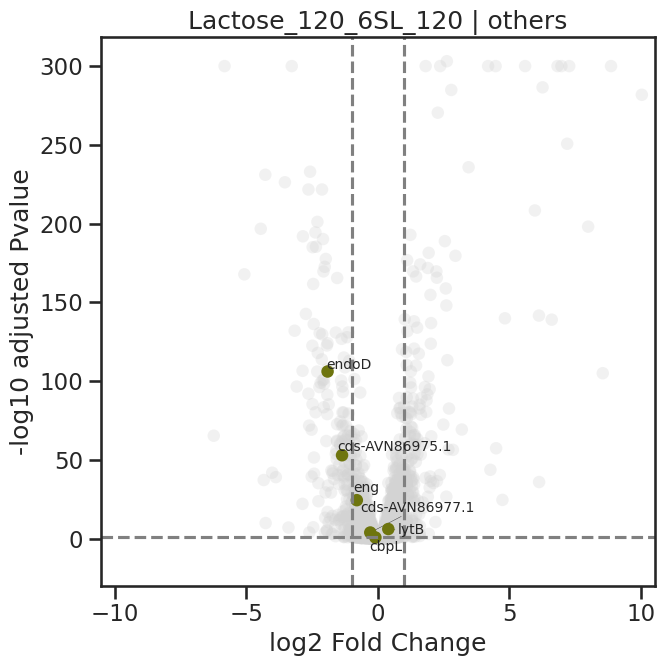

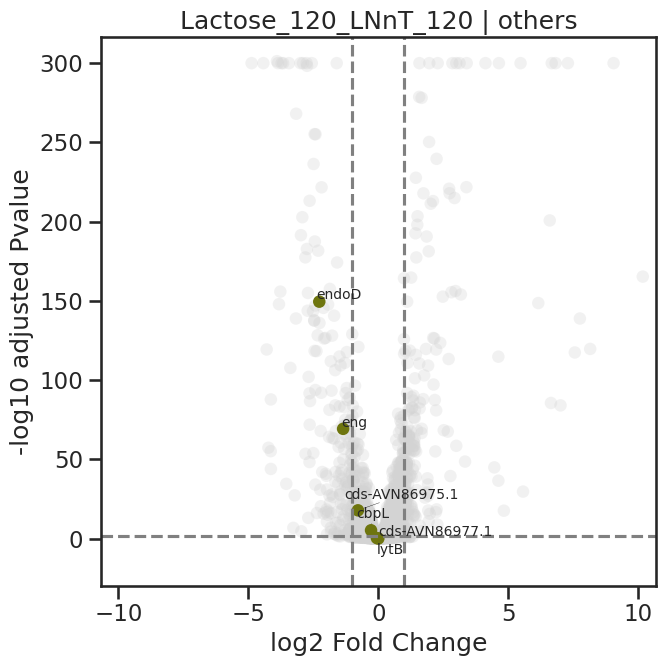

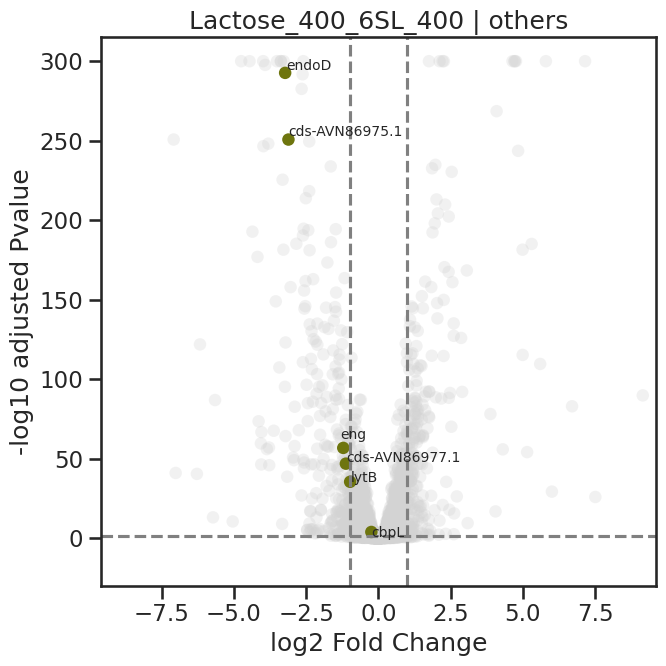

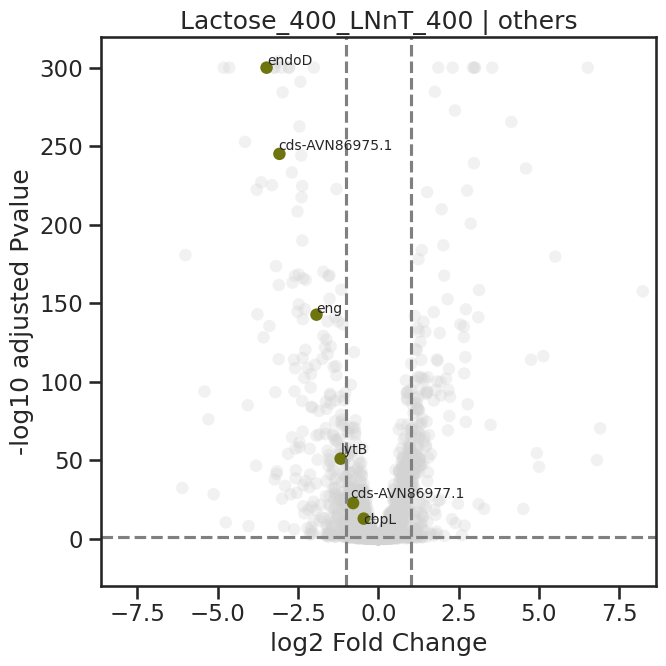

In [59]:
# files of interest are:
files_name = ["DGE_Lactose_120_6SL_120.tsv", "DGE_Lactose_120_LNnT_120.tsv", "DGE_Lactose_400_6SL_400.tsv", "DGE_Lactose_400_LNnT_400.tsv"]

# Loop through DGE files
for fname in files_name:
    file = out_dir_V / fname
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")

    for pathway_name, genes in pathways.items():
        volcano(
            df,
            gff_df=dgVf,
            title=f"{contrast_name} | {pathway_name}",
            fc_thresh=fc_thresh,
            p_thresh=p_thresh,
            highlight_genes=genes,
            highlight_color=dict_colors[pathway_name],
            save_path=out_dir_V / f"{contrast_name}_{pathway_name}_volcano.svg"
        )

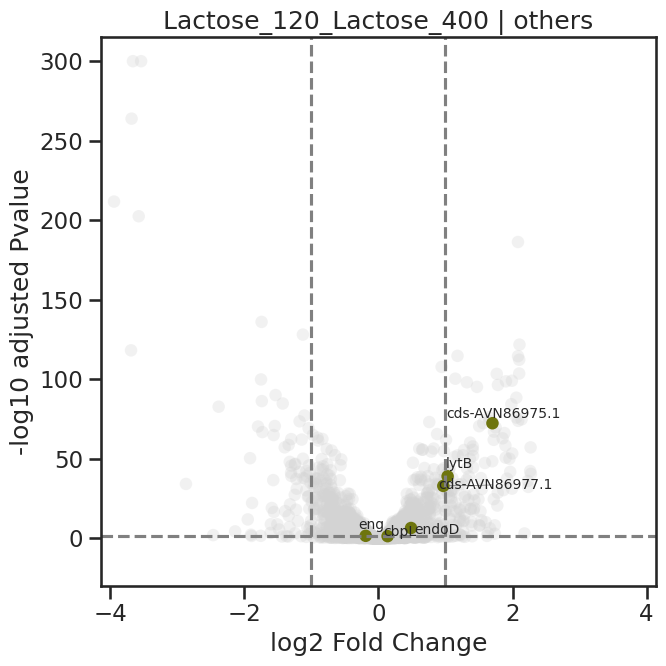

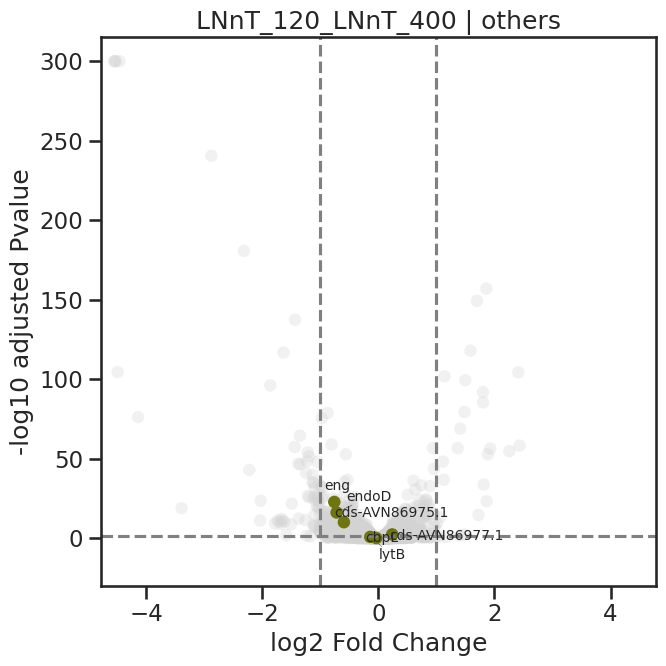

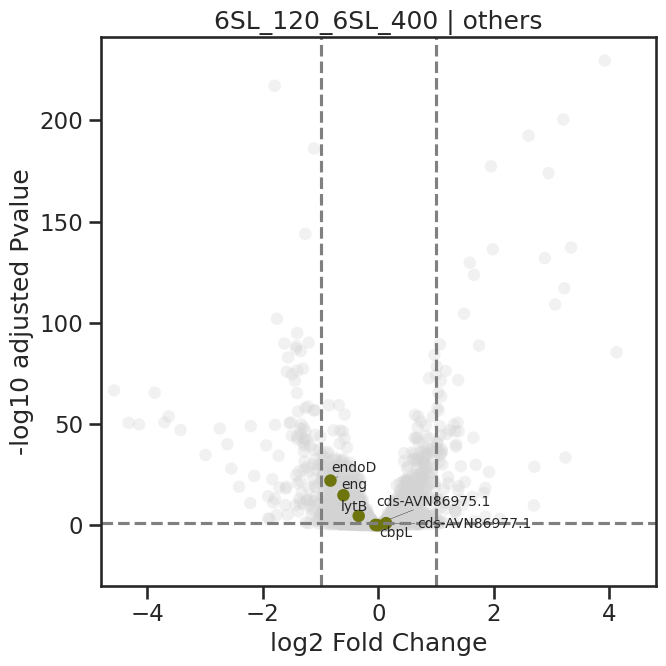

In [60]:
# files of interest are:
files_name = ["DGE_Lactose_120_Lactose_400.tsv", "DGE_LNnT_120_LNnT_400.tsv", "DGE_6SL_120_6SL_400.tsv"]

# Loop through DGE files
for fname in files_name:
    file = out_dir_V / fname
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")

    for pathway_name, genes in pathways.items():
        volcano(
            df,
            gff_df=dgVf,
            title=f"{contrast_name} | {pathway_name}",
            fc_thresh=fc_thresh,
            p_thresh=p_thresh,
            highlight_genes=genes,
            highlight_color=dict_colors[pathway_name],
            save_path=out_dir_V / f"{contrast_name}_{pathway_name}_volcano.svg"
        )

In [41]:
def volcano_highlight(df, gff_df=None, title="", fc_thresh=1, p_thresh=0.05,
                 highlight_genes=None, highlight_color="red", save_path=None):

    # Detect columns
    fc_col = [c for c in df.columns if 'log2' in c.lower() and 'fold' in c.lower()][0]
    padj_col = [c for c in df.columns if 'padj' in c.lower()][0]
    gene_col = next((c for c in df.columns if c.lower() in ['gene','feature_id','id']), 'gene')

    df = df.copy()
    df['gene'] = df[gene_col]

    # ---- map locus_tag to gene_id ----
    if gff_df is not None:
        locus_to_geneid = dict(zip(gff_df["locus_tag"], gff_df["gene_id"]))
        df["gene_id"] = df["gene"].map(locus_to_geneid).fillna(df["gene"])
    else:
        df["gene_id"] = df["gene"]

    # stats
    df[padj_col] = df[padj_col].replace(0, 1e-300)
    df['-log10(padj)'] = -np.log10(df[padj_col])

    # labels (use gene_id for consistency)
    df['label'] = df["gene_id"]

    # ---- highlight pathway genes ----
    if highlight_genes is not None:
        highlight_set = set(highlight_genes)
        df['color'] = np.where(df['gene_id'].isin(highlight_set),
                               highlight_color, 'lightgrey')
    else:
        df['color'] = 'grey'

    # ---- Plot ----
    plt.figure(figsize=(7,7))

    if highlight_genes is not None:
        # background points (non-highlighted)
        bg = df[~df['gene_id'].isin(highlight_set)]
        plt.scatter(bg[fc_col], bg['-log10(padj)'],
                    c='lightgrey', alpha=0.3, edgecolors='none', zorder=1)

        # highlighted points (alpha = 1)
        hl = df[df['gene_id'].isin(highlight_set)]
        plt.scatter(hl[fc_col], hl['-log10(padj)'],
                    c=highlight_color, alpha=1, edgecolors='none', zorder=2)
    else:
        plt.scatter(df[fc_col], df['-log10(padj)'],
                    c='grey', alpha=0.7, edgecolors='none', zorder=1)

    plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--')
    plt.axvline(fc_thresh, color='grey', linestyle='--')
    plt.axvline(-fc_thresh, color='grey', linestyle='--')

    # ---- Annotate ONLY highlighted genes with |log2FC| > fc_thresh ----
    if highlight_genes is not None:
        sub = df[df['gene_id'].isin(highlight_set) & (df[fc_col].abs() > fc_thresh)]
        texts = [
            plt.text(r[fc_col], r['-log10(padj)'], r['label'], fontsize=10)
            for _, r in sub.iterrows()
        ]
        adjust_text(texts,
                    arrowprops=dict(arrowstyle='-', color='black', lw=0.25))

    # Limits
    xlim = max(abs(df[fc_col].max()), abs(df[fc_col].min()))
    plt.xlim(-xlim*1.05, xlim*1.05)
    plt.ylim(-30, df['-log10(padj)'].max()*1.05)

    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted Pvalue")
    plt.title(title)
    plt.gca().set_facecolor("white")

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)

    plt.show()

In [47]:
pathways = {
    "CRISPRi_hits":CRISPRi_hits
}

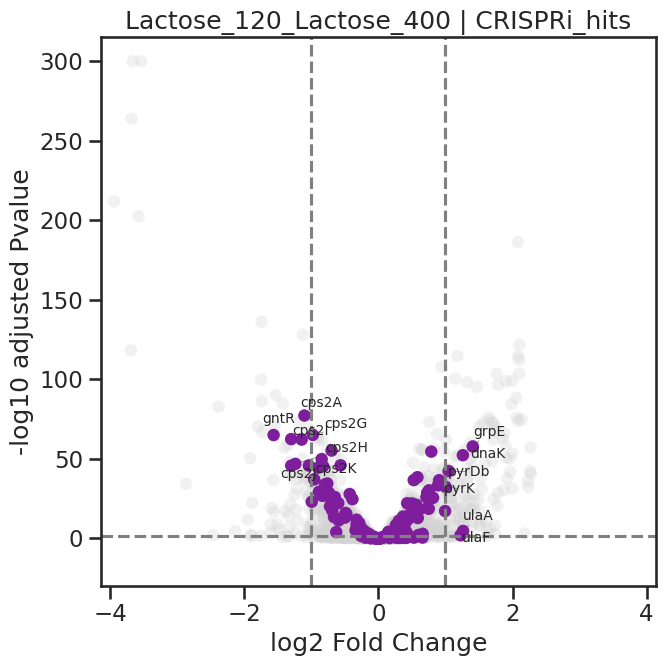

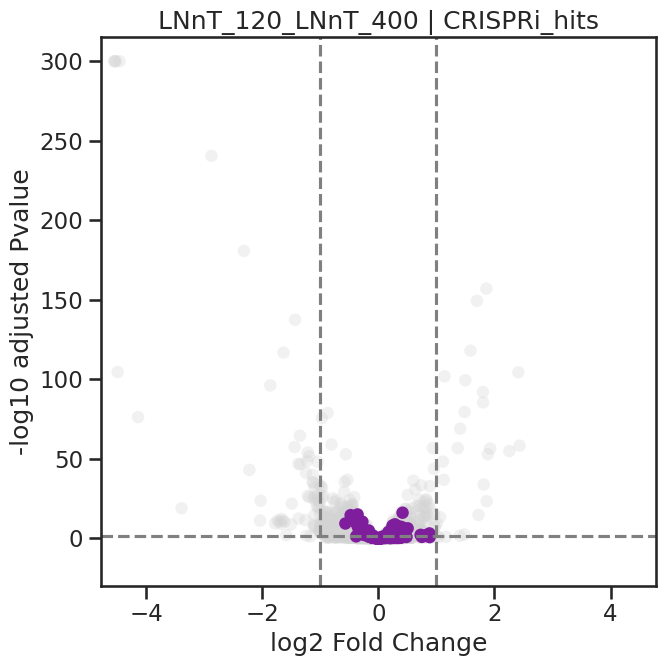

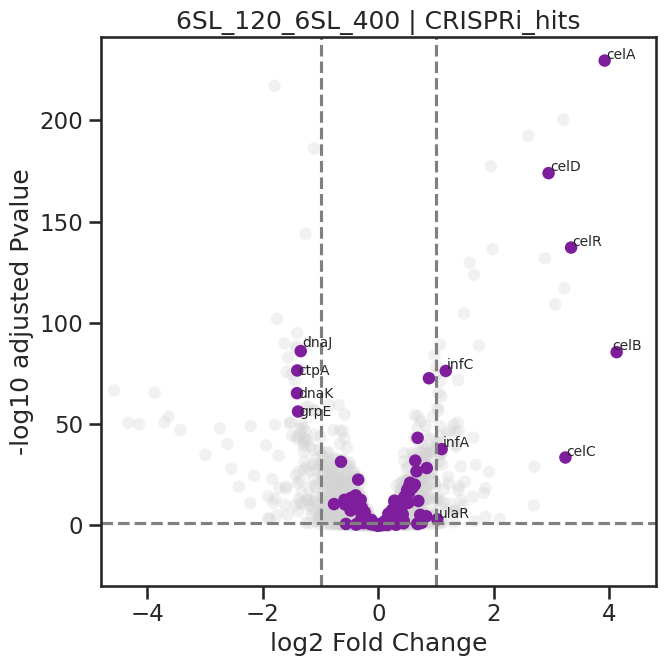

In [49]:
files_name = ["DGE_Lactose_120_Lactose_400.tsv", "DGE_LNnT_120_LNnT_400.tsv", "DGE_6SL_120_6SL_400.tsv"]

# Loop through DGE files
for fname in files_name:
    file = out_dir_V / fname
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")

    for pathway_name, genes in pathways.items():
        volcano_highlight(
            df,
            gff_df=dgVf,
            title=f"{contrast_name} | {pathway_name}",
            fc_thresh=fc_thresh,
            p_thresh=p_thresh,
            highlight_genes=genes,
            highlight_color=dict_colors[pathway_name],
            save_path=out_dir_V / f"{contrast_name}_{pathway_name}_volcano.svg"
        )

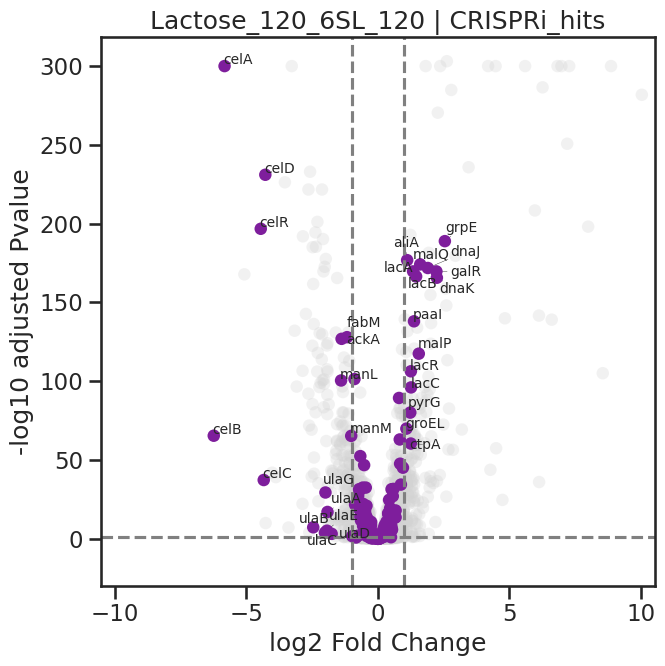

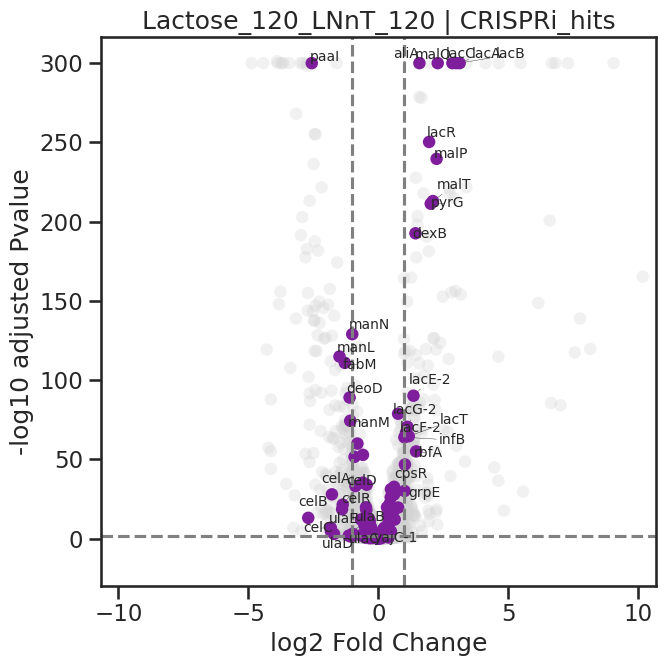

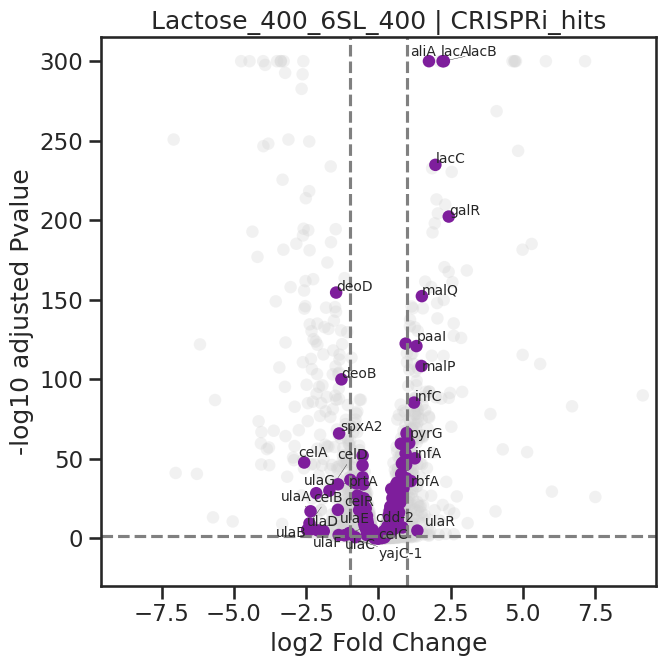

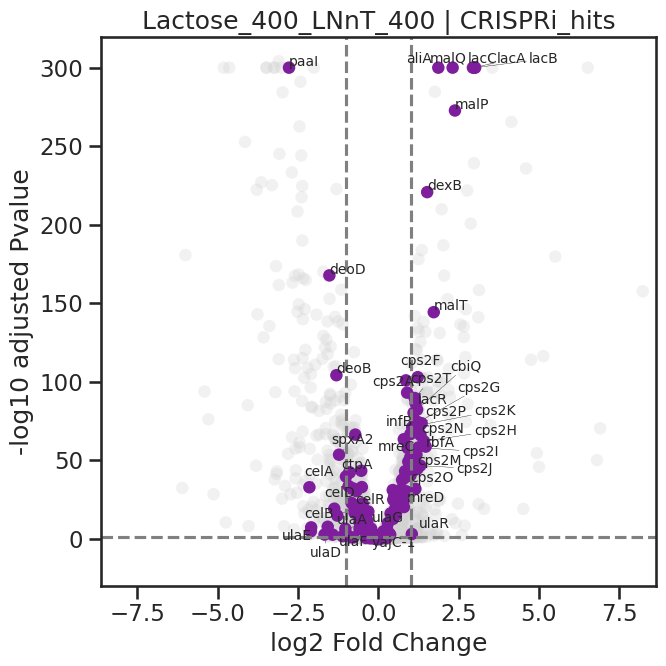

In [42]:
# files of interest are:
files_name = ["DGE_Lactose_120_6SL_120.tsv", "DGE_Lactose_120_LNnT_120.tsv", "DGE_Lactose_400_6SL_400.tsv", "DGE_Lactose_400_LNnT_400.tsv"]

# Loop through DGE files
for fname in files_name:
    file = out_dir_V / fname
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")

    for pathway_name, genes in pathways.items():
        volcano_highlight(
            df,
            gff_df=dgVf,
            title=f"{contrast_name} | {pathway_name}",
            fc_thresh=fc_thresh,
            p_thresh=p_thresh,
            highlight_genes=genes,
            highlight_color=dict_colors[pathway_name],
            save_path=out_dir_V / f"{contrast_name}_{pathway_name}_volcano.png"
        )